본 코드에서는 이전 단계(전통적인 ML)에서 이어서 보다 발전된 형태의 앙상블 기반 모델에 대해 성능 평가를 수행한다.

사용할 모델은 다음과 같다.

- Extra Trees Classifier (Bagging Ensemble)
- XGBoost Classifier (Boosting Ensemble)
- HOG + SVM (Hybrid Ensemble)

이 세 모델은 모두 단일 전통 ML 모델보다 더 높은 표현력과 일반화 능력을 가진다.
본 Notebook에서는 COLOR MNIST(npz파일)을 불러오고, 각 앙상블 모델의 성능을 비교분석한다.

1. 데이터 불러오기

In [ ]:
import numpy as np 
from sklearn.model_selection import train_test_split

data = np.load("../assets/mnist_colored_fg_bg.npz")

#파일에 어떤 키들이 저장되어 있는지 확인
print("\n파일에 저장된 키 목록:", list(data.keys()))

X = data['images']
y = data['digit_labels']

# 먼저 Train / Test로 나누기
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train_full = Train + Validation 나누기
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.125, random_state=42, stratify=y_train_full
)

print("Train :", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)
print("Validation :", X_val.shape, y_val.shape)


파일에 저장된 키 목록: ['images', 'digit_labels', 'fg_labels', 'bg_labels']
Train : (42000, 28, 28, 3) (42000,)
Test : (12000, 28, 28, 3) (12000,)
Validation : (6000, 28, 28, 3) (6000,)


2. 전처리

In [12]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)

print("Flatten shape :",X_train_flat.shape, X_test_flat.shape, X_val_flat.shape)

Flatten shape : (42000, 2352) (12000, 2352) (6000, 2352)


Base Ensemble Models 성능 평가

# 개요

이 Notebook에서는 기본적인 앙상블 계열의 세 모델을 평가한다.

# 1) Extra Trees(Extremely Randomized Trees)
Bagging 기반 앙상블
Decision Tree를 대량으로 랜덤하게 재구성하여 안정적인 성능 제공

# 2) XGBoost
Gradient Boosting 기반 앙상블
오차를 순차적으로 보완하는 방식으로 강력한 예측 성능

# 3) HOG + SVM
HOG : Histogram of Oriented Gradients (특징 추출기)
SVM : Margin 기반 분류기
서로 다른 알고리즘을 결합한 Hybrid Ensemble 구조

각 모델은 기존 단일 ML 모델보다 더욱 강력한 일반화 성능을 가진다는 점에서
기본 앙상블 모델(Base Ensemble Models)로 정의한다.

Extra Trees Classifier

In [13]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score

extra_trees = ExtraTreesClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

extra_trees.fit(X_train_flat, y_train)

pred_val_et = extra_trees.predict(X_val_flat)
pred_test_et = extra_trees.predict(X_test_flat)

acc_val_et = accuracy_score(y_val, pred_val_et)
acc_test_et = accuracy_score(y_test, pred_test_et)

print("Extra Trees Classifier Accuracy (Validation):", acc_val_et)
print("Extra Trees Classifier Accuracy (Test):", acc_test_et)

Extra Trees Classifier Accuracy (Validation): 0.9245
Extra Trees Classifier Accuracy (Test): 0.9280833333333334


XGBoost Classifier

In [22]:
import xgboost
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

print(xgboost.__version__)

xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    objective="multi:softprob",
    num_class=10,
    eval_metric="mlogloss",
    random_state=42
)

xgb.fit(
    X_train_flat, y_train,
    eval_set=[(X_val_flat, y_val)],
    verbose=False
)
pred_val_xgb = xgb.predict(X_val_flat)
pred_test_xgb = xgb.predict(X_test_flat)

acc_val_xgb = accuracy_score(y_val, pred_val_xgb)
acc_test_xgb = accuracy_score(y_test, pred_test_xgb)

print("HOG + SVM Accuracy (Validation):", acc_val_xgb)
print("HOG + SVM Accuracy (Test):", acc_test_xgb)

3.1.2
HOG + SVM Accuracy (Validation): 0.9456666666666667
HOG + SVM Accuracy (Test): 0.9476666666666667


HOG + SVM(Hybrid Ensemble)

In [23]:
import cv2
from sklearn.svm import LinearSVC

hog = cv2.HOGDescriptor(
    _winSize=(28, 28),
    _blockSize=(14, 14),
    _blockStride=(7, 7),
    _cellSize=(7, 7),
    _nbins=9
)

# HOG 특징 변환 함수
def extract_hog_features(images):
    features = []
    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        hog_feat = hog.compute(gray)
        features.append(hog_feat.flatten())
    return np.array(features)

# HOG Feature 생성
X_train_hog = extract_hog_features(X_train)
X_val_hog = extract_hog_features(X_val)
X_test_hog = extract_hog_features(X_test)

# SVM 학습
svm = LinearSVC()
svm.fit(X_train_hog, y_train)

pred_val_svm = svm.predict(X_val_hog)
pred_test_svm = svm.predict(X_test_hog)

acc_val_svm = accuracy_score(y_val, pred_val_svm)
acc_test_svm = accuracy_score(y_test, pred_test_svm)

print("HOG + SVM Accuracy (Validation):", acc_val_svm)
print("HOG + SVM Accuracy (Test):", acc_test_svm)

HOG + SVM Accuracy (Validation): 0.9791666666666666
HOG + SVM Accuracy (Test): 0.9819166666666667


성능 비교 테이블 출력

In [24]:
import pandas as pd

results = pd.DataFrame({
    "Model" : ["Extra Trees", "XGBoost", "HOG + SVM"],
    "Accuracy" : [acc_test_et, acc_test_xgb, acc_test_svm]
}
)

results

,Model,Accuracy
0,Extra Trees,0.928083
1,XGBoost,0.947667
2,HOG + SVM,0.981917


공통 오분류 분석 함수(모든 모델에 사용가능)
각 모델이 오분류한 이미지들을 시각화하고, 어떤 패턴을 놓쳤는지 분석할 수 있도록 하는 코드
오분류 인덱스 추출 -> 이미지 표시 -> 예측값/정답 같이 표기

In [26]:
import matplotlib.pyplot as plt

def show_misclassified(X_test, y_test, y_pred, model_name, num_samples=12):
    '''
    X_test : 원본 이미지(N, 28, 28, 3)
    y_test : 실제 라벨
    y_pred : 모델 예측 라벨
    '''

    mis_idx = np.where(y_test != y_pred)[0]
    print(f"[{model_name}] Total misclassified:", len(mis_idx))

    if len(mis_idx) == 0:
        print("No misclassifications.")
        return
    
    # 일부만 시각화
    mis_idx = mis_idx[:num_samples]
    cols = 4
    rows = (len(mis_idx) + cols -1) // cols

    plt.figure(figsize=(12, 3 * rows))
    for i, idx in enumerate(mis_idx):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(X_test[idx])
        plt.title(f"True: {y_test[idx]}\nPred: {y_pred[idx]}")
        plt.axis("off")

        plt.suptitle(f"{model_name} - Misclassified Samples", fontsize=16)
        plt.tight_layout()
        plt.show()

/home/parkjinseo/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


추가 분석 코드 : 어떤 숫자를 많이 틀렸는지 confusion matrix도 출력

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def show_confusion(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

[Extra Trees] Total misclassified: 863


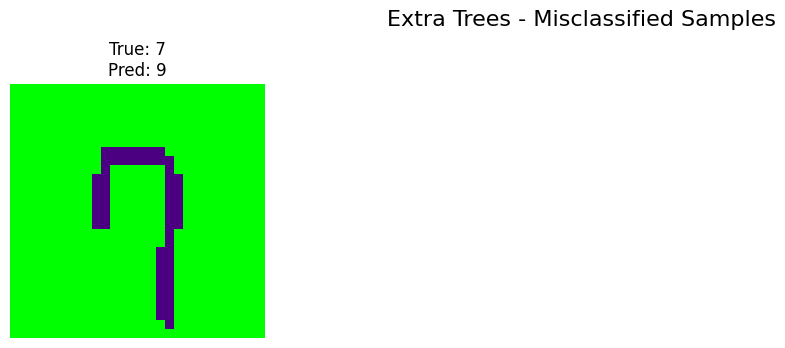

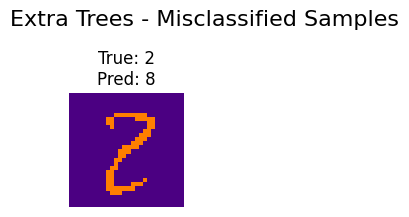

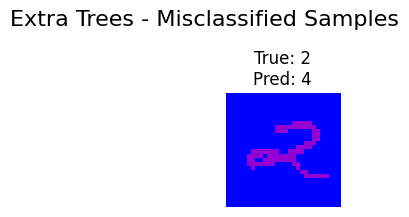

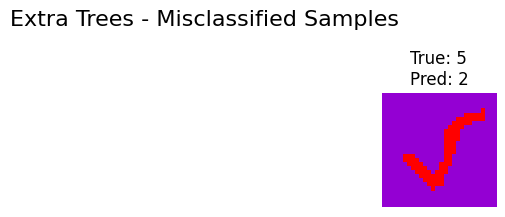

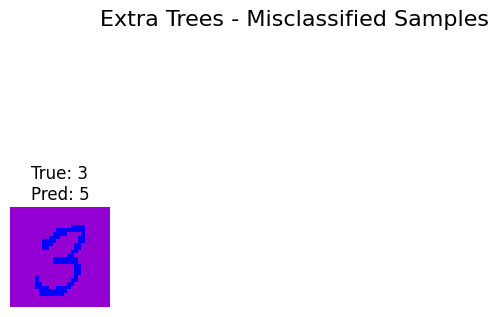

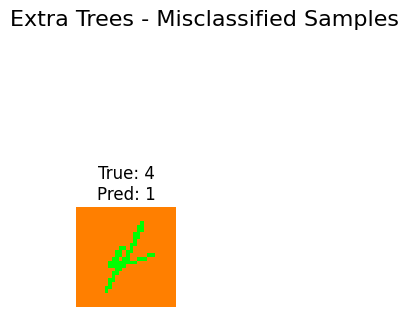

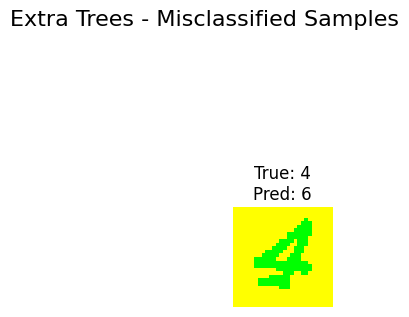

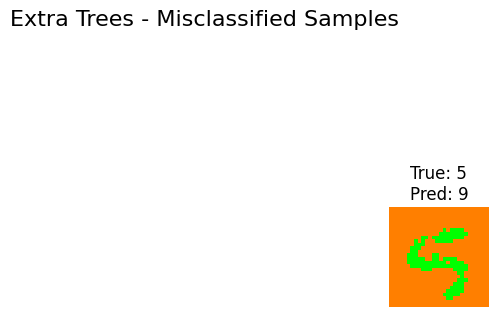

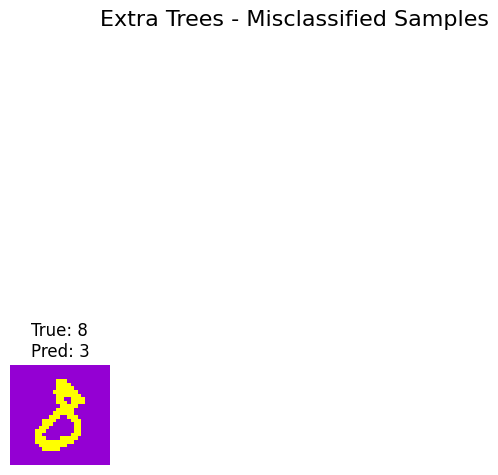

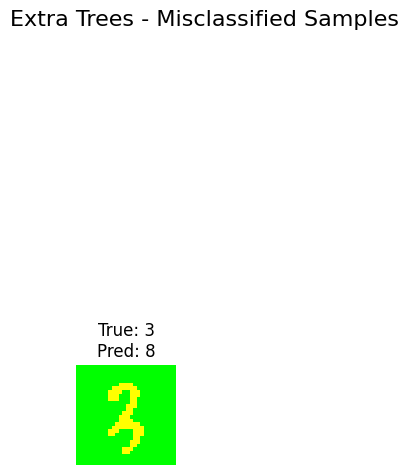

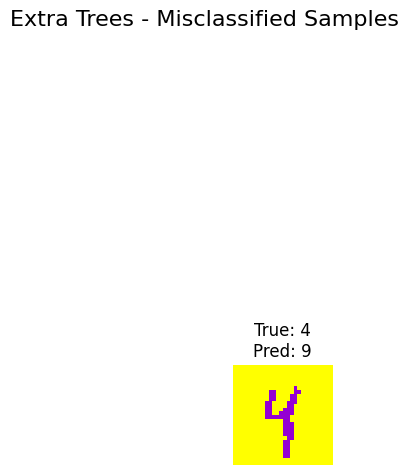

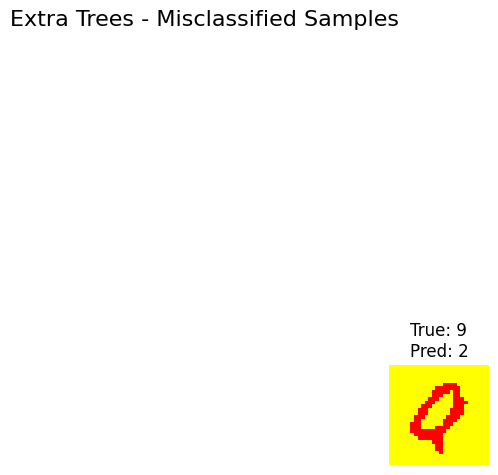

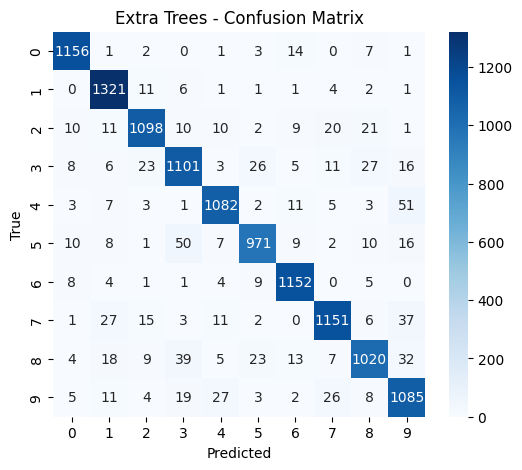

In [29]:
#Extra Trees 오분류 분석
show_misclassified(X_test, y_test, pred_test_et, "Extra Trees")
show_confusion(y_test, pred_test_et, "Extra Trees")

[XGBoost] Total misclassified: 628


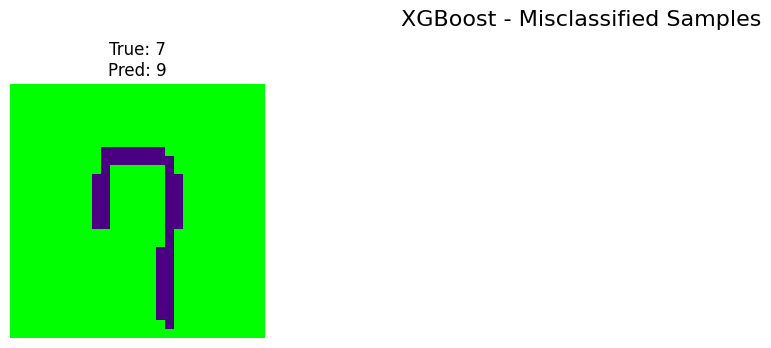

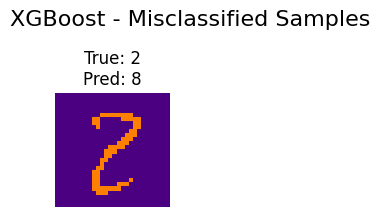

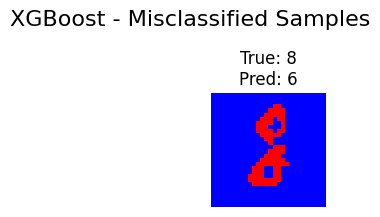

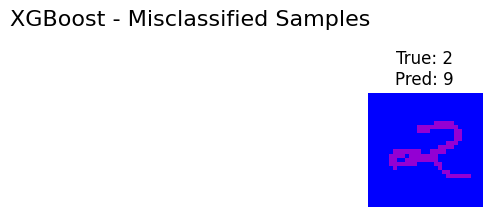

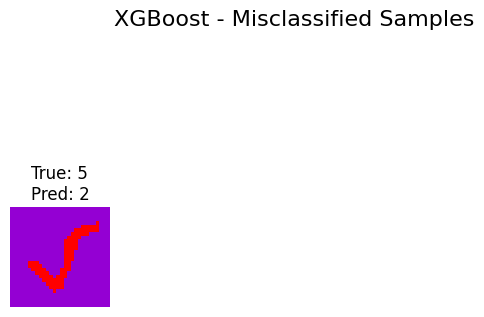

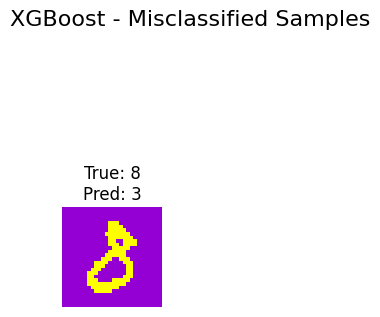

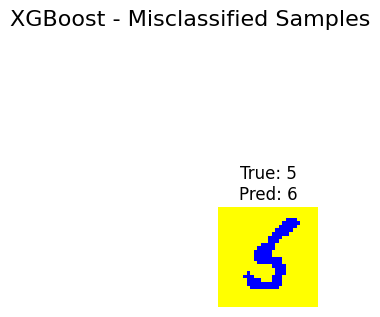

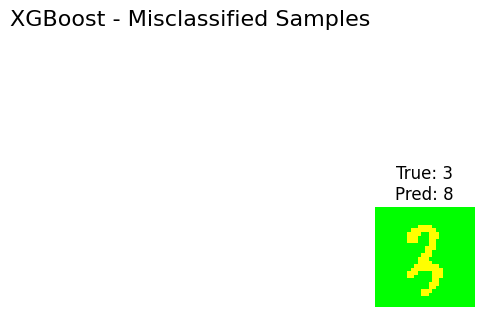

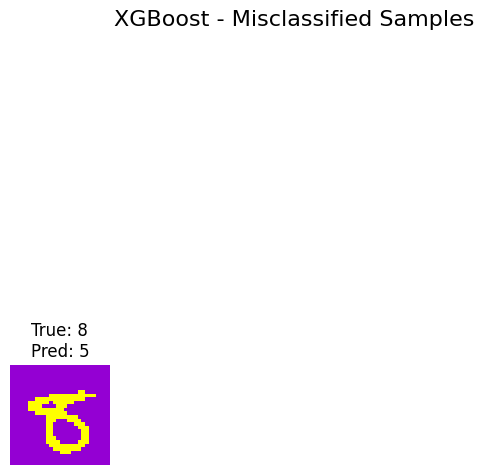

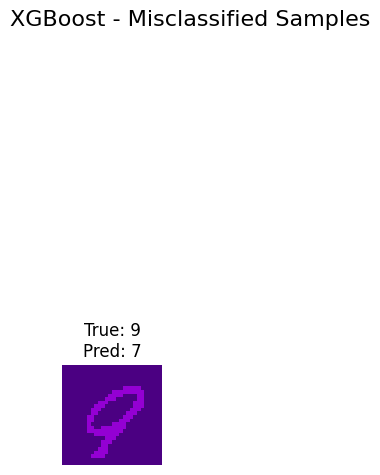

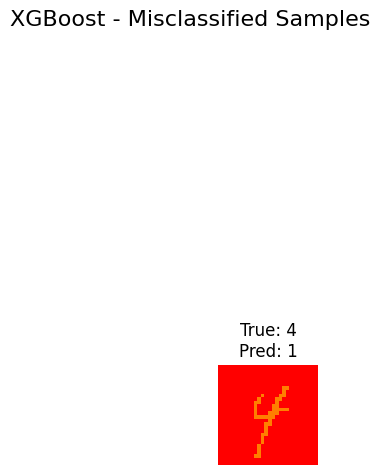

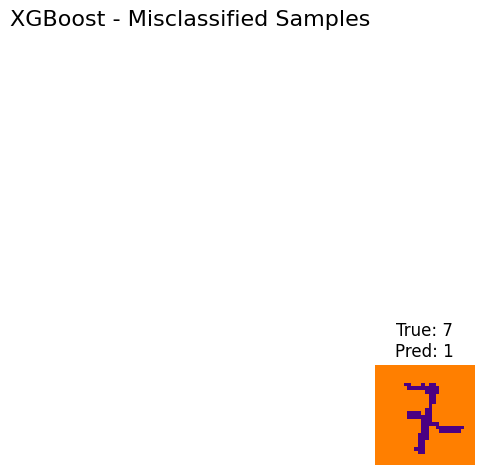

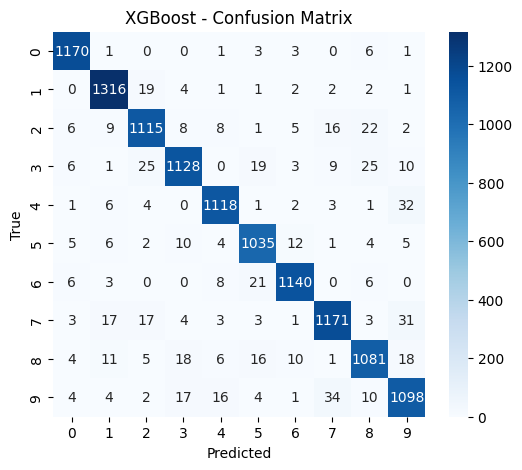

In [30]:
#XGBoost 오분류 분석
show_misclassified(X_test, y_test, pred_test_xgb, "XGBoost")
show_confusion(y_test, pred_test_xgb, "XGBoost")

[HOG + SVM] Total misclassified: 217


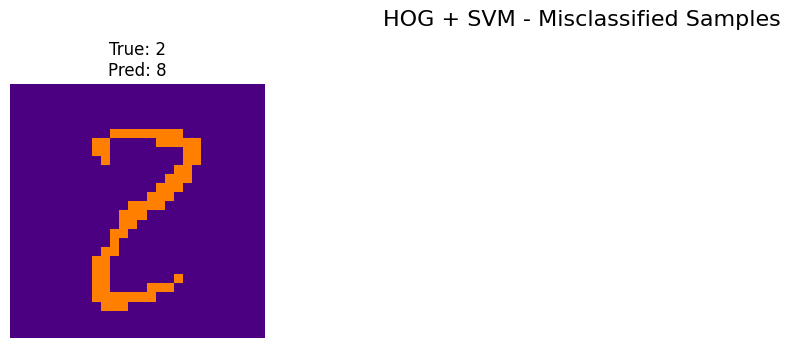

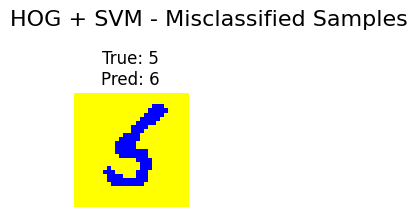

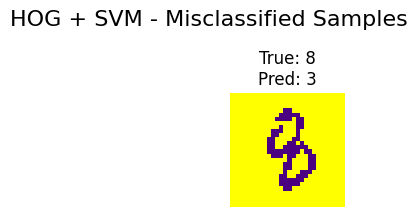

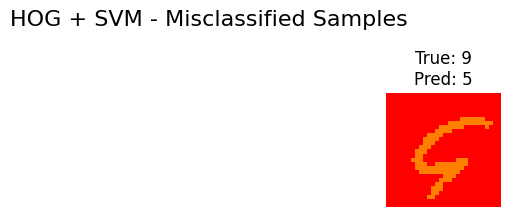

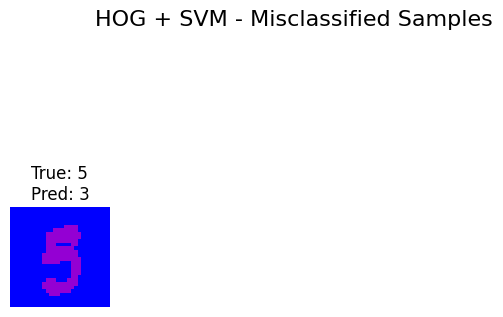

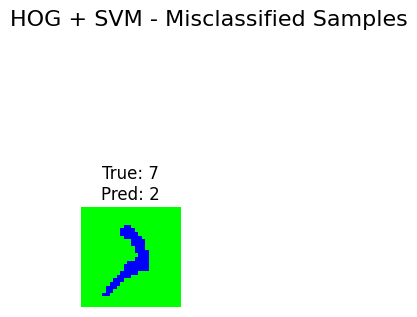

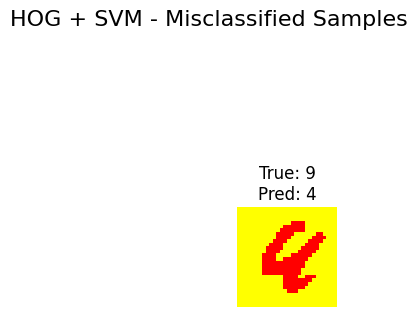

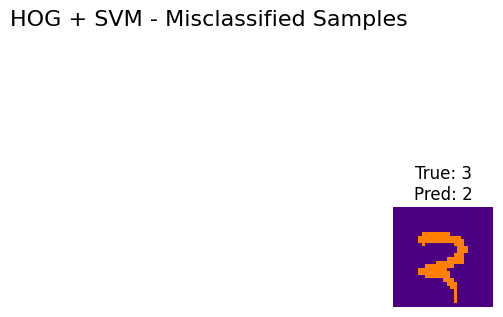

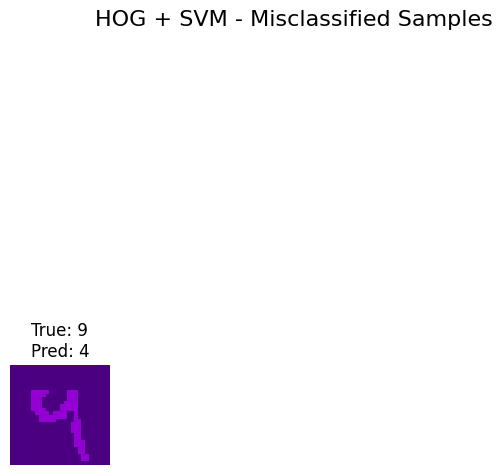

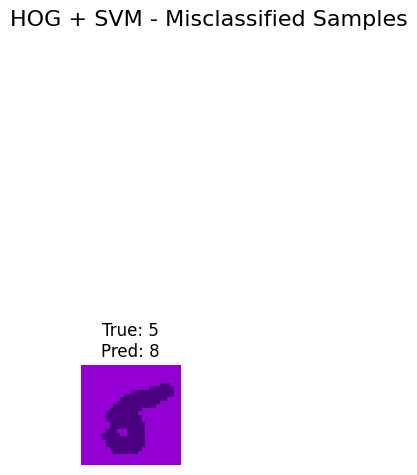

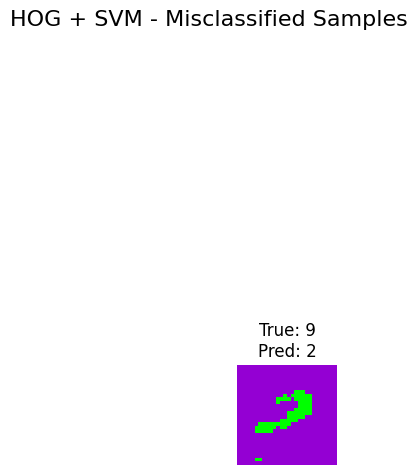

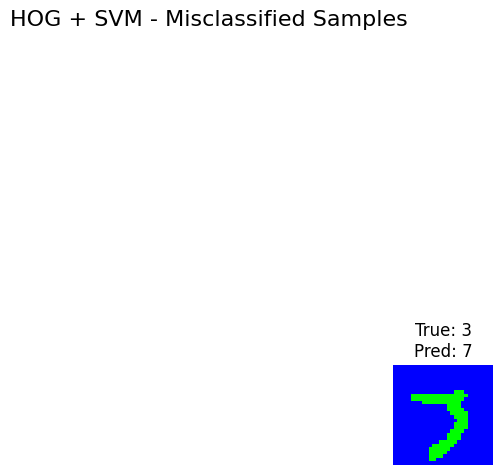

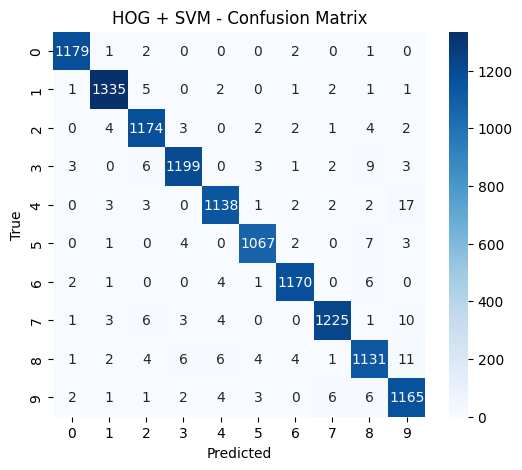

In [31]:
#HOG + SVM 오분류 분석
show_misclassified(X_test, y_test, pred_test_svm, "HOG + SVM")
show_confusion(y_test, pred_test_svm, "HOG + SVM")